## **Sample Dataset**

The dataset contains advertising budgets (TV, Radio, Newspaper) and corresponding Sales (in thousands of units).

**Goal:** Understand how each advertising channel affects sales, and predict sales based on budgets.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Advertising.csv")
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


## **Exploring the Data**

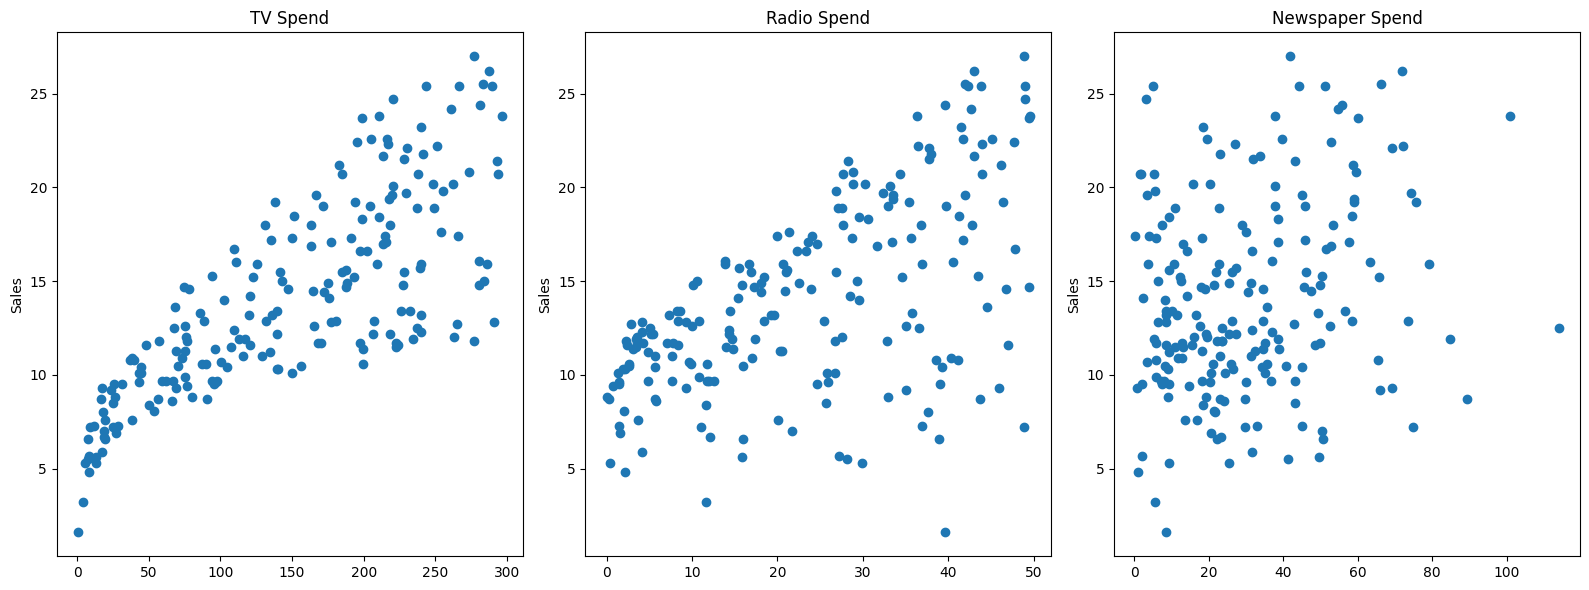

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16,6))

axes[0].scatter(df['TV'], df['sales'])
axes[0].set_title("TV Spend")
axes[0].set_ylabel("Sales")

axes[1].scatter(df['radio'], df['sales'])
axes[1].set_title("Radio Spend")
axes[1].set_ylabel("Sales")

axes[2].scatter(df['newspaper'], df['sales'])
axes[2].set_title("Newspaper Spend")
axes[2].set_ylabel("Sales")

plt.tight_layout()


Is there a relationship between *total* advertising spend and *sales*?

In [4]:
df['total_spend'] = df['TV'] + df['radio'] + df['newspaper']

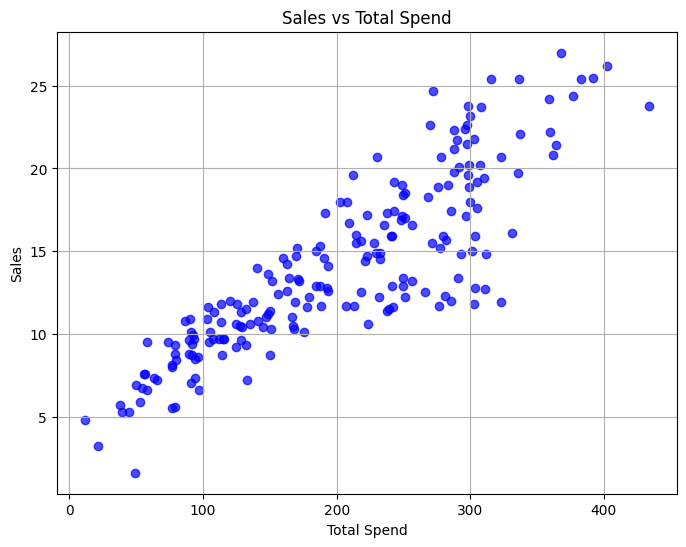

In [5]:
plt.figure(figsize=(8,6))
plt.scatter(df['total_spend'], df['sales'], color='blue', alpha=0.7)
plt.xlabel('Total Spend')
plt.ylabel('Sales')
plt.title('Sales vs Total Spend')
plt.grid(True)
plt.show()


## **Least Squares Line**

Recall:
$$y=mx+b$$
solve for m and b
<br>
or
<br>
$$ \hat{y} = \beta_0 + \beta_1X$$
solve for $\beta_0$ and $\beta_1$


<br><br>
### **Fitting Lines with NumPy**

In linear regression, our goal is to find the line that best describes the relationship between a feature `x` and a target `y`.

One simple and powerful way to do this using NumPy is with the `np.polyfit` function.

`np.polyfit` works analytically using Ordinary Least Squares (OLS)

What it does: `np.polyfit` computes the coefficients of a polynomial that best fits your data using the least squares method.

Why it’s useful:

You can quickly fit a straight line (degree=1) or more complex curves (degree>1).


In [6]:
X = df['total_spend']
y = df['sales']

In [7]:
help(np.polyfit)

Help on _ArrayFunctionDispatcher in module numpy:

polyfit(x, y, deg, rcond=None, full=False, w=None, cov=False)
    Least squares polynomial fit.

    .. note::
       This forms part of the old polynomial API. Since version 1.4, the
       new polynomial API defined in `numpy.polynomial` is preferred.
       A summary of the differences can be found in the
       :doc:`transition guide </reference/routines.polynomials>`.

    Fit a polynomial ``p(x) = p[0] * x**deg + ... + p[deg]`` of degree `deg`
    to points `(x, y)`. Returns a vector of coefficients `p` that minimises
    the squared error in the order `deg`, `deg-1`, ... `0`.

    The `Polynomial.fit <numpy.polynomial.polynomial.Polynomial.fit>` class
    method is recommended for new code as it is more stable numerically. See
    the documentation of the method for more information.

    Parameters
    ----------
    x : array_like, shape (M,)
        x-coordinates of the M sample points ``(x[i], y[i])``.
    y : array_like, sh

In [8]:
np.polyfit(X,y,1)

array([0.04868788, 4.24302822])

What the array means:

- For deg=1 (linear fit), NumPy returns coefficients in descending powers of x.
- Index 0 → slope (m)
- Index 1 → intercept (b

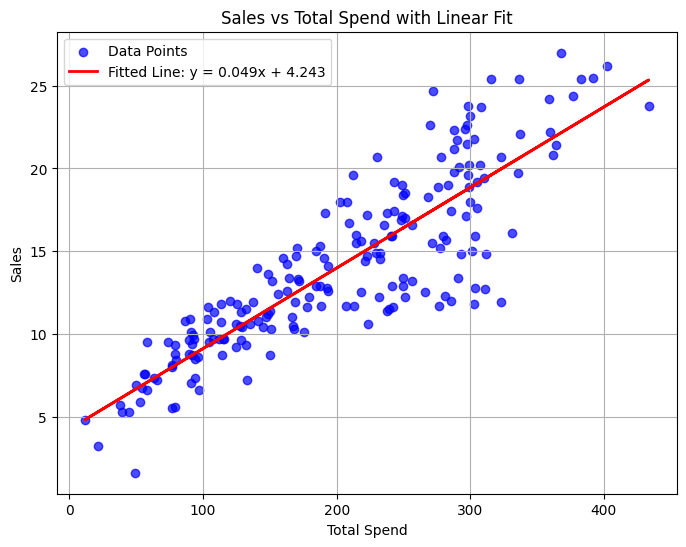

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Example data
X = df['total_spend']
y = df['sales']

# Fit a line using NumPy
coefficients = np.polyfit(X, y, 1)  # deg=1 for linear
slope, intercept = coefficients

# Create predicted y values for the fitted line
y_hat = slope * X + intercept

# Plot scatter data
plt.figure(figsize=(8,6))
plt.scatter(X, y, color='blue', alpha=0.7, label='Data Points')

# Plot fitted line
plt.plot(X, y_hat, color='red', linewidth=2, label=f'Fitted Line: y = {slope:.3f}x + {intercept:.3f}')

# Add labels, title, legend, grid
plt.xlabel('Total Spend')
plt.ylabel('Sales')
plt.title('Sales vs Total Spend with Linear Fit')
plt.legend()
plt.grid(True)
plt.show()


What if we have new total spend data and we want to predict the sale.

In [10]:
spend = 250
predicted_sales =  slope * spend + intercept
predicted_sales

np.float64(16.41499804579837)

## **Exploring Higher-Degree Polynomial Fits**

So far, we’ve fitted a straight line (degree 1) to our data using `np.polyfit`. But what if the relationship between our features and target is non-linear?

- NumPy’s np.polyfit can fit polynomials of any degree.

- Increasing the degree allows the model to capture curvature in the data.

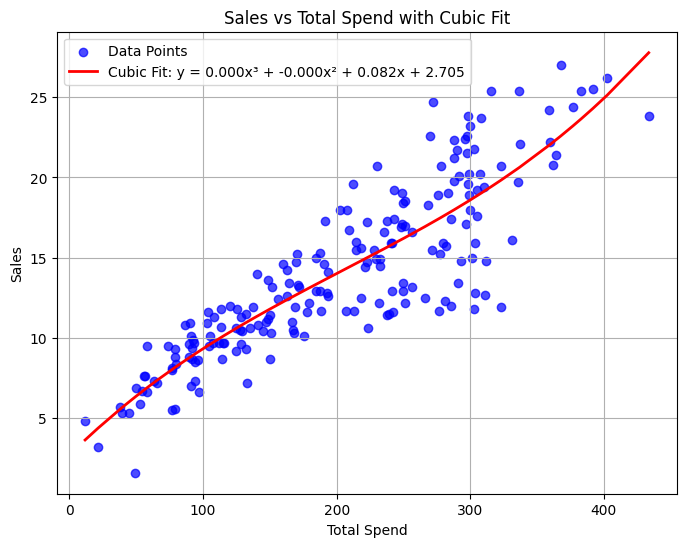

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Example data
X = df['total_spend'].values
y = df['sales'].values

# Fit a cubic polynomial
coefficients = np.polyfit(X, y, 3)
a, b, c, d = coefficients

# Sort X for smooth plotting
X_sorted = np.sort(X)
y_hat = a*X_sorted**3 + b*X_sorted**2 + c*X_sorted + d

# Plot scatter data
plt.figure(figsize=(8,6))
plt.scatter(X, y, color='blue', alpha=0.7, label='Data Points')

# Plot smooth cubic curve
plt.plot(X_sorted, y_hat, color='red', linewidth=2,
         label=f'Cubic Fit: y = {a:.3f}x³ + {b:.3f}x² + {c:.3f}x + {d:.3f}')

plt.xlabel('Total Spend')
plt.ylabel('Sales')
plt.title('Sales vs Total Spend with Cubic Fit')
plt.legend()
plt.grid(True)
plt.show()


**Caution:** Higher-degree polynomials can easily **overfit** — they may perfectly match the training points but fail to generalize to new data.

## **Multiple Features**

Previously, we looked at linear regression with a single feature (total_spend) to predict sales. But in reality, sales can depend on multiple factors. For example, in our dataset, we have TV, Radio, and Newspaper advertising budgets as separate features.

Using multiple features allows us to:

- Capture the contribution of each advertising channel to sales.
- Potentially improve our predictions by accounting for all available information.
- Understand which features have the most influence on the target.

We'll now fit a linear model with multiple features using NumPy — essentially solving the multivariate ordinary least squares problem analytically.

In [12]:
X = df[['TV','radio','newspaper']]
y = df['sales']

In [13]:
np.polyfit(X,y,1)

TypeError: expected 1D vector for x

**Polyfit only works with a 1D X array!**

<br><br>

# **Introduction to Scikit-Learn**


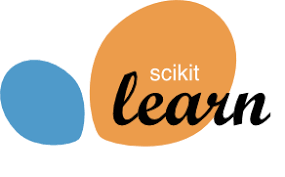

**Scikit-Learn** (sklearn) is one of the most popular Python libraries for machine learning.

It provides a consistent platform for building, training, and evaluating models, from simple linear regression to complex ensemble methods.

Key benefits for students and practitioners:

- **Easy to use** – models have a consistent .fit(), .predict(), and .score() interface.
- **Extensive documentation** – clear guidance for almost every type of machine learning task.
- **Flexible** – works with NumPy arrays or pandas DataFrames.
- **Integrated evaluation tools** – metrics, cross-validation, and train-test splitting.

Even though we previously solved linear regression analytically with NumPy, Scikit-Learn lets us:

- Scale up to larger datasets.
- Easily split data into training and testing sets.
- Evaluate model performance with built-in metrics.
- Extend to multiple features and different algorithms without rewriting math.

Think of Scikit-Learn as a ready-made toolkit for machine learning: it handles the “boring math” behind the scenes so we can focus on building, evaluating, and improving models.

In [14]:
# import sklearn linear model
from sklearn.linear_model import LinearRegression


# Create an instance of the model
model = LinearRegression()

# fit the model to data
model.fit(X,y)

LinearRegression()

In [15]:
model.intercept_

np.float64(2.938889369459412)

In [16]:
# Print coefficients
features = X.columns
coeffs = model.coef_
intercept = model.intercept_
for f, c in zip(features, coeffs):
    print(f"{f}: {c:.3f}")

print(f"Intercept: {intercept:.3f}")

TV: 0.046
radio: 0.189
newspaper: -0.001
Intercept: 2.939


## **Optional**

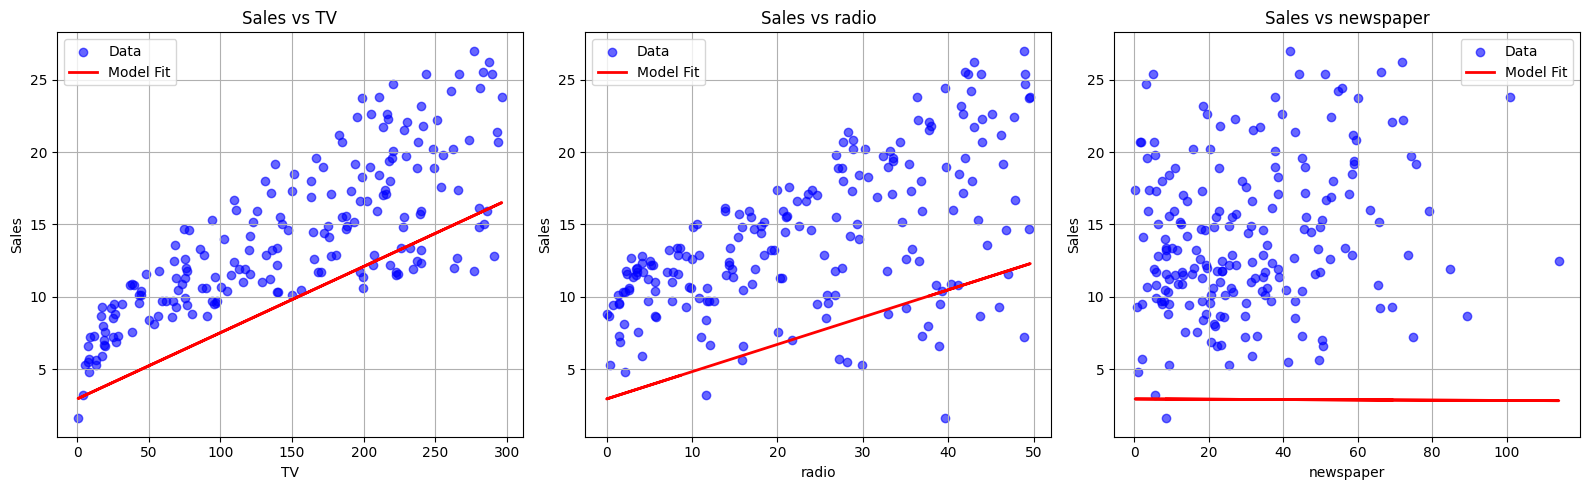

In [17]:

# Plot each feature vs sales with fitted line
plt.figure(figsize=(16,5))

for i, f in enumerate(features):
    plt.subplot(1, 3, i+1)

    # Scatter plot
    plt.scatter(X[f], y, alpha=0.6, color='blue', label='Data')

    # Fitted line: y_hat = intercept + coef * feature
    y_hat = intercept + coeffs[i] * X[f]  # keep other features constant
    plt.plot(X[f], y_hat, color='red', linewidth=2, label='Model Fit')

    plt.xlabel(f)
    plt.ylabel('Sales')
    plt.title(f'Sales vs {f}')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()






## **Partial Regression Plots (Added Variable Plots)**

To address the issue of visualizing individual feature effects in a multiple linear regression, we can use **Partial Regression Plots**.

These plots show the relationship between the response variable (Y) and a single predictor variable (X), after accounting for the linear effects of the other predictor variables in the model.

**How they work:**

1.  **Residuals of Y on other X's:** The vertical axis represents the residuals from regressing the target variable (`sales`) on all other independent variables (e.g., `radio` and `newspaper` when looking at `TV`).
2.  **Residuals of X on other X's:** The horizontal axis represents the residuals from regressing the *predictor of interest* (e.g., `TV`) on all other independent variables (`radio` and `newspaper`).

The slope of the regression line in a partial regression plot is the estimated coefficient for that predictor in the multiple linear regression model. This visualization helps to isolate the unique contribution of each predictor to the model, after removing the influence of other variables.

In [20]:
import statsmodels.formula.api as smf
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Create a formula string for the OLS model
# Sales is dependent, TV, radio, newspaper are independent
formula = 'sales ~ TV + radio + newspaper'

# Fit the OLS model using statsmodels
model_sm = smf.ols(formula=formula, data=df).fit()

# Print the summary of the model to see coefficients and R-squared
#print(model_sm.summary())


Now, let's generate the partial regression plots for each feature.

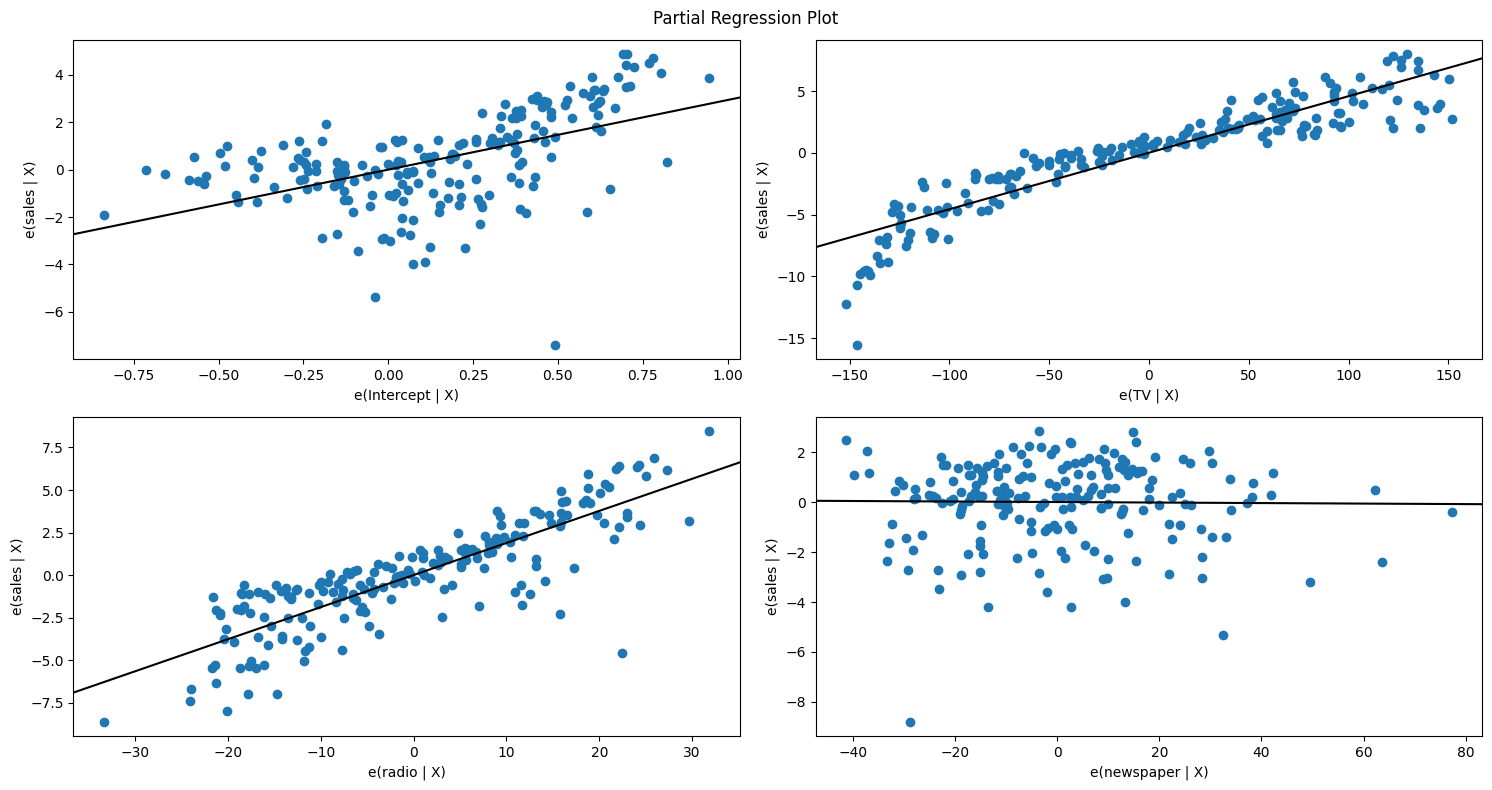

In [19]:
fig = plt.figure(figsize=(15, 8))
fig = sm.graphics.plot_partregress_grid(model_sm, fig=fig)
fig.tight_layout(pad=1.0)
plt.show()

As you can see, these plots give a much clearer picture of the *isolated* relationship between each advertising channel and sales, after accounting for the other variables in the multiple regression model. The slope of the line in each plot corresponds to the coefficient of that variable in the `model_sm` summary.

<br>

## **Understanding Higher Degree Polynomials**

### **1. Interpreting `np.polyfit` with higher degrees:**

When you use `np.polyfit(X, y, degree)` with a `degree` greater than 1, you are indeed assuming that the relationship between that single input variable `X` and the output `y` is **non-linear**, specifically, a polynomial relationship. For instance:

*   `degree=1`: `y = a*X + b` (linear)
*   `degree=2`: `y = a*X^2 + b*X + c` (quadratic)
*   `degree=3`: `y = a*X^3 + b*X^2 + c*X + d` (cubic)

This allows the model to capture curves and bends in the data, rather than being restricted to a straight line. The example you saw earlier with `total_spend` and `degree=3` was a demonstration of fitting a cubic (non-linear) relationship to a single feature.

### **2. Scikit-learn equivalent for higher degree polynomials:**

Scikit-learn's `LinearRegression` model, by itself, always fits a linear relationship between the *provided features* and the target. However, you can use a clever trick to achieve polynomial regression with `LinearRegression` by first **transforming your features**.

The equivalent in scikit-learn involves two main steps, typically combined in a `Pipeline`:

1.  **`PolynomialFeatures`**: This transformer from `sklearn.preprocessing` creates new features by raising the existing features to specified powers (and also includes interaction terms if you have multiple features). For example, if you have a feature `X` and set `degree=2`, it will create `X` and `X^2` as new features.
2.  **`LinearRegression`**: After `PolynomialFeatures` generates these new, higher-order terms (e.g., `X^2`, `X^3`), you then pass these *new* features to a standard `LinearRegression` model. The `LinearRegression` model will then fit a linear combination of these polynomial features, effectively creating a polynomial regression.

Let's demonstrate this using the `total_spend` feature from our dataset to replicate the cubic fit we did with `np.polyfit`.

<br>

## **When and Where Gradient Descent is Used**

**Gradient Descent** is a general optimization algorithm used to minimize a cost function. In the context of linear regression, it iteratively adjusts the model's coefficients (weights) to reduce the difference between predicted and actual values.

### **Why not always OLS?**

While OLS provides an exact solution, it can be computationally expensive or even impossible in certain scenarios:

1.  **Very Large Datasets:** For datasets with millions or billions of samples, calculating the exact OLS solution (which involves matrix inversions) becomes too slow and memory-intensive.
2.  **Regularization (L1/L2):** When you add regularization terms (like Lasso or Ridge Regression) to prevent overfitting, the cost function no longer has a simple closed-form solution. Gradient descent (or its variants) is then used to find the optimal coefficients.
3.  **Non-Linear Models / Neural Networks:** Gradient descent is the fundamental algorithm for training complex models like neural networks, where analytical solutions are non-existent.


### **Scikit-learn and Gradient Descent**

While `LinearRegression` uses OLS, scikit-learn provides other models that explicitly use gradient descent (or its variants like Stochastic Gradient Descent) for optimization, especially when dealing with large datasets or models with regularization. A prime example is `SGDRegressor`.

Let's demonstrate how to use `SGDRegressor` to fit a linear model to our advertising data.